# 06 · Safety

Sources: OpenStreetMap India via Geofabrik (ODbL) · MoRTH Annual Report 2024-25, Appendix-2 (as on 31.12.2024) · WorldPop 2020 1 km (CC BY 4.0) · GHSL built-up (CC BY 4.0) · MoRTH Road Accidents in India 2024 · NHAI Datalake — aggregates only (ADR-0014). Rebuild everything: `cd ml && uv run python -m fields.national_highways all`.

National 2024 totals come from Road Accidents in India 2024. State rates use NHAI crash points for 2022–23 (full reporting years) over NHAI's completed NH length; they cover NHAI-managed stretches and reporting completeness varies by state.

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

ML = Path.cwd().resolve().parents[1]  # ml/notebooks/national_highways -> ml
sys.path.insert(0, str(ML))
from fields.national_highways import analysis as nh

A = nh.A
SUMMARY = json.loads((A / "summary.json").read_text())
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

In [2]:
rai = SUMMARY["rai_national"]
display(pd.DataFrame(rai["nh_series"]).T.rename_axis("year"))
pd.DataFrame(rai["by_agency_2024"]).T

,accidents,deaths
year,,
2020,119615,50251
2021,128825,56007
2022,151997,61038
2023,150177,63112
2024,150958,64772


,accidents,deaths
nhai,108240,49675
state_pwd,35118,11998
other,7600,3099


,crashes,deaths,fatal_crashes,nhai_nh_km,deaths_per_100km_per_year
state,,,,,
Tamil Nadu,"12,448.00","1,907.00","1,754.00","7,128.23",13.38
Delhi,483.00,18.00,17.00,73.97,12.17
Karnataka,"8,100.00","1,167.00","1,050.00","7,646.06",7.63
Kerala,"2,626.00",260.00,239.00,"1,740.76",7.47
Haryana,"3,843.00",387.00,346.00,"2,695.35",7.18
Telangana,"4,688.00",681.00,611.00,"4,829.68",7.05
Andhra Pradesh,"8,819.00","1,033.00",943.00,"7,841.30",6.59
Rajasthan,"9,938.00","1,069.00",945.00,"9,723.33",5.50
Madhya Pradesh,"6,675.00",921.00,770.00,"9,019.42",5.11


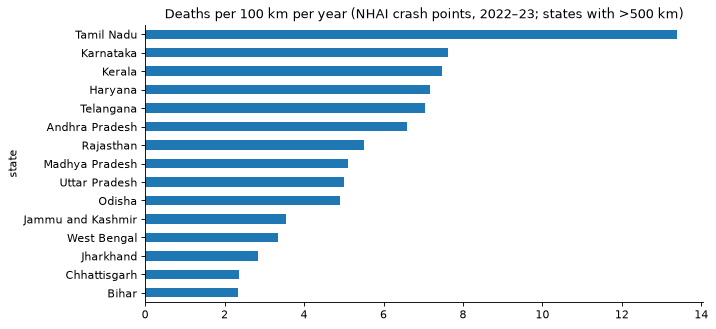

In [3]:
saf = pd.read_csv(A / "safety_by_state.csv", index_col=0)
big = saf[(saf.index != "India") & (saf.nhai_nh_km > 500)]
big.sort_values("deaths_per_100km_per_year").tail(15).plot.barh(y="deaths_per_100km_per_year", legend=False, title="Deaths per 100 km per year (NHAI crash points, 2022–23; states with >500 km)");
saf.round(2)

## How complete is NHAI's crash layer?

In [4]:
cr = gpd.read_parquet(nh.OUT / "nhai_crashes.parquet")
yearly = cr.groupby(cr.date.dt.year).size()
display(yearly)
nhai = SUMMARY["rai_national"]["by_agency_2024"]["nhai"]
deaths = cr.groupby(cr.date.dt.year).deaths.sum()
print(f"2023 layer: {yearly[2023]:,} crashes = {yearly[2023] / nhai['accidents']:.0%} of the {nhai['accidents']:,} accidents RAI 2024 reports on NHAI roads; "
      f"{deaths[2023]:,.0f} deaths = {deaths[2023] / nhai['deaths']:.0%} of {nhai['deaths']:,}")

date
2020     1784
2021      775
2022    38957
2023    49992
dtype: int64

2023 layer: 49,992 crashes = 46% of the 108,240 accidents RAI 2024 reports on NHAI roads; 6,274 deaths = 13% of 49,675


## Crashes by lane band
Per km, not per vehicle-km: wider roads carry far more traffic, and the layer covers NHAI-run corridors best. Read it as where crashes concentrate, not as the risk of a trip.

In [5]:
band = pd.read_csv(A / "crash_rate_by_lane_band.csv", index_col=0)
print(f"{SUMMARY['crash_snapped_share']:.0%} of crash points lie within {nh.CFG['crash_snap_m']} m of an NHAI stretch")
band.round(2)

88% of crash points lie within 200 m of an NHAI stretch


,crashes,deaths,km,crashes_per_100km_per_year,deaths_per_100km_per_year
band,,,,,
2,17639,2623,"92,773.36",9.51,1.41
4,47164,5805,"31,729.07",74.32,9.15
6+,13008,1480,"5,097.15",127.60,14.52
<2,141,37,"7,158.39",0.98,0.26


In [6]:
gpd.read_parquet(nh.OUT / "nhai_black_spots.parquet")["status_of_"].value_counts(dropna=False)

status_of_
Completed/Rectified    4008
NaN                     486
Under Construction        5
Name: count, dtype: int64